In [5]:
import os
import glob
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt

#descargar la última version del dataset
path = kagglehub.dataset_download("sansuthi/dry-bean-dataset")
print("Path to dataset files:", path)
print("******************************")

#ver los archivos del dataset
for raiz, _, archivos in os.walk(path):
    for a in archivos:
        print(os.path.join(raiz, a))

#cargar el archivo (detecta CSV o Excel automáticamente)
csvs = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
xlsx = glob.glob(os.path.join(path, "**", "*.xlsx"), recursive=True)

if csvs:
    archivo = csvs[0]
    df = pd.read_csv(archivo)
elif xlsx:
    archivo = xlsx[0]
    df = pd.read_excel(archivo)
else:
    raise FileNotFoundError("No encontré ningún .csv ni .xlsx en la carpeta descargada.")

print("\nArchivo cargado:", archivo)

#normalizar el nombre de la columna de clase por si viene como 'class'
df.columns = [c.strip() for c in df.columns]
col_clase = next(c for c in df.columns if c.lower() == "class")
if col_clase != "Class":
    df = df.rename(columns={col_clase: "Class"})

#estructura general
#se espera la tupla (13611, 17)
print("\nFilas y columnas:", df.shape)
print("Valores faltantes:", df.isna().sum().sum())
print("Columnas:", list(df.columns))

#conteo y porcentaje por clase
conteo = df["Class"].value_counts()
tabla = pd.DataFrame({
    "Muestras": conteo,
    "Porcentaje": (conteo / len(df) * 100).round(1),
})
print("\n")
print("******************************")
print(tabla)
print("******************************")
print("Total:", tabla["Muestras"].sum())


Using Colab cache for faster access to the 'dry-bean-dataset' dataset.
Path to dataset files: /kaggle/input/dry-bean-dataset
******************************
/kaggle/input/dry-bean-dataset/Dry_Bean.csv

Archivo cargado: /kaggle/input/dry-bean-dataset/Dry_Bean.csv

Filas y columnas: (13611, 17)
Valores faltantes: 0
Columnas: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']


******************************
          Muestras  Porcentaje
Class                         
DERMASON      3546        26.1
SIRA          2636        19.4
SEKER         2027        14.9
HOROZ         1928        14.2
CALI          1630        12.0
BARBUNYA      1322         9.7
BOMBAY         522         3.8
******************************
Total: 13611


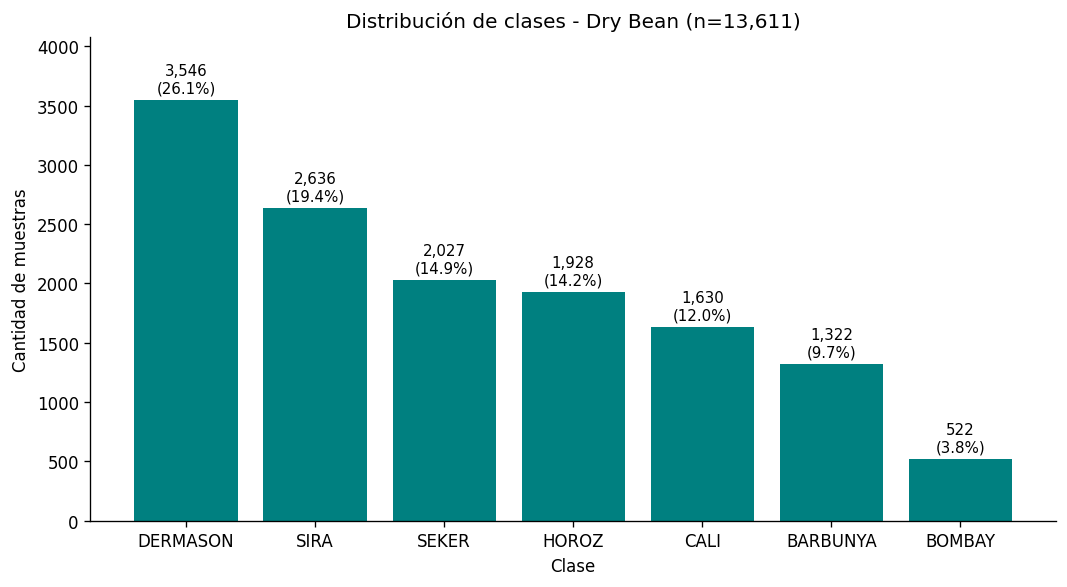

In [6]:
#ordenar de mayor a menor
datos = tabla.sort_values("Muestras", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5), dpi=120)
barras = ax.bar(datos.index, datos["Muestras"], color="teal")

#etiqueta de conteo y porcentaje
for barra, muestras, pct in zip(barras, datos["Muestras"], datos["Porcentaje"]):
    ax.text(barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 40,
            f"{muestras:,}\n({pct}%)",
            ha="center", va="bottom", fontsize=9)

ax.set_title(f"Distribución de clases - Dry Bean (n={len(df):,})")
ax.set_xlabel("Clase")
ax.set_ylabel("Cantidad de muestras")
#espacio para las etiquetas
ax.set_ylim(0, datos["Muestras"].max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
#para insertarla en el documento
plt.savefig("distribucion_clases.png", dpi=150)
plt.show()